In [1]:
import sys

sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import pykitti

from pathlib import Path

# Load KITTI
base = Path.home() / 'SensorTrust' / 'datasets' / 'kitti'
data = pykitti.raw(base_path=str(base), date='2011_09_26', drive='0009')

from src.proxies.gps_proxy import extract_all_gps_proxies
from src.proxies.imu_proxy import extract_all_imu_proxies
from src.proxies.camera_proxy import extract_all_camera_proxies
from src.proxies.lidar_proxy import extract_all_lidar_proxies

from src.attacks.imu_attack import (
    constant_bias,
    linear_drift,
    gaussian_noise,
    burst_noise,
    scale_factor_attack,
    attack_imu_proxies
)

from src.attacks.camera_attack import (
    gaussian_noise,
    salt_pepper_noise,
    brightness_shift,
    motion_blur,
    occlusion,
    freeze_frames,
    drop_frames
)

from src.features.normalization import MotionNormalizer
from src.features.f1_kinematic import extract_all_f1_features

print(f"Frames: {len(data.oxts)}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Frames: 447


In [2]:
'''Extract Clean IMU Proxies'''
imu_clean = extract_all_imu_proxies(data.oxts, dt=0.1035)

print(f"   IMU proxies extracted")
print(f"   Keys: {list(imu_clean.keys())}")
print(f"   Frames: {len(imu_clean['yaw_rate'])}")
print(f"   yaw_rate mean: {np.mean(imu_clean['yaw_rate']):.4f} rad/s")
print(f"   delta_v mean:  {np.mean(imu_clean['delta_v']):.4f} m/s")

   IMU proxies extracted
   Keys: ['delta_v', 'yaw_rate']
   Frames: 447
   yaw_rate mean: 0.0279 rad/s
   delta_v mean:  nan m/s


In [3]:
'''Generate All 5 Attacked Versions'''
imu_bias   = attack_imu_proxies(imu_clean, attack_type="bias",  bias=0.05)
imu_drift  = attack_imu_proxies(imu_clean, attack_type="drift", final_bias=0.1)
imu_noise  = attack_imu_proxies(imu_clean, attack_type="noise", std=0.02)
imu_burst  = attack_imu_proxies(imu_clean, attack_type="burst", start_frame=200, duration=30, amplitude=0.3)
imu_scale  = attack_imu_proxies(imu_clean, attack_type="scale", scale=1.2)

all_attacks = {
    "Constant Bias":  imu_bias,
    "Linear Drift":   imu_drift,
    "Gaussian Noise": imu_noise,
    "Burst Noise":    imu_burst,
    "Scale Factor":   imu_scale,
}

colors = ["tomato", "darkorange", "mediumorchid", "dodgerblue", "seagreen"]
attack_names = list(all_attacks.keys())

print(" All 5 attacks generated")
for name, attacked in all_attacks.items():
    diff = np.mean(np.abs(attacked["yaw_rate"] - imu_clean["yaw_rate"]))
    print(f"   {name:<20} | mean |yaw_rate diff|: {diff:.5f}")

 All 5 attacks generated
   Constant Bias        | mean |yaw_rate diff|: 0.05000
   Linear Drift         | mean |yaw_rate diff|: 0.05000
   Gaussian Noise       | mean |yaw_rate diff|: 0.01583
   Burst Noise          | mean |yaw_rate diff|: 0.01464
   Scale Factor         | mean |yaw_rate diff|: 0.00940


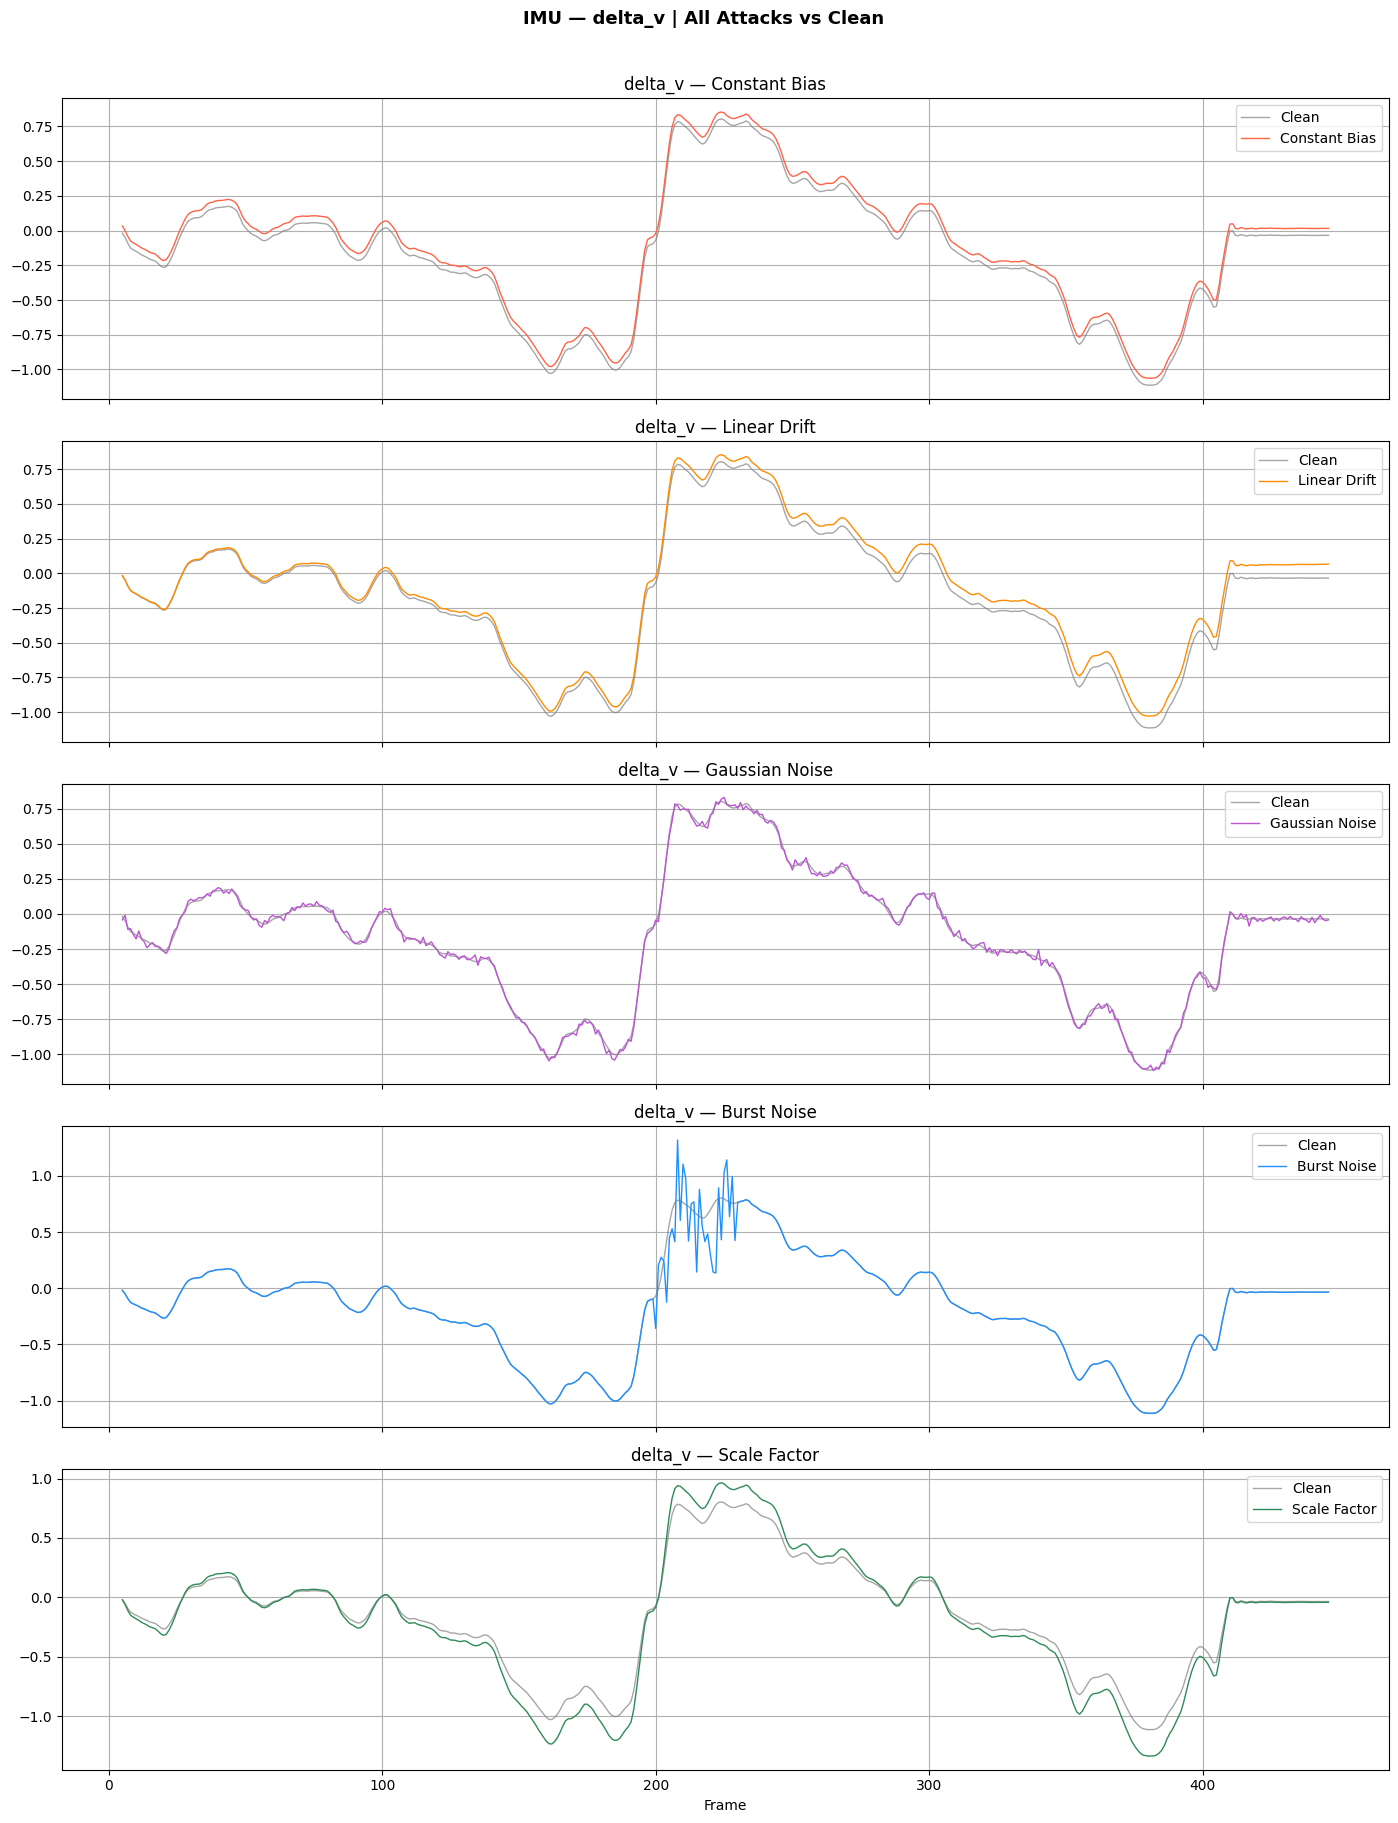

delta_v plotted


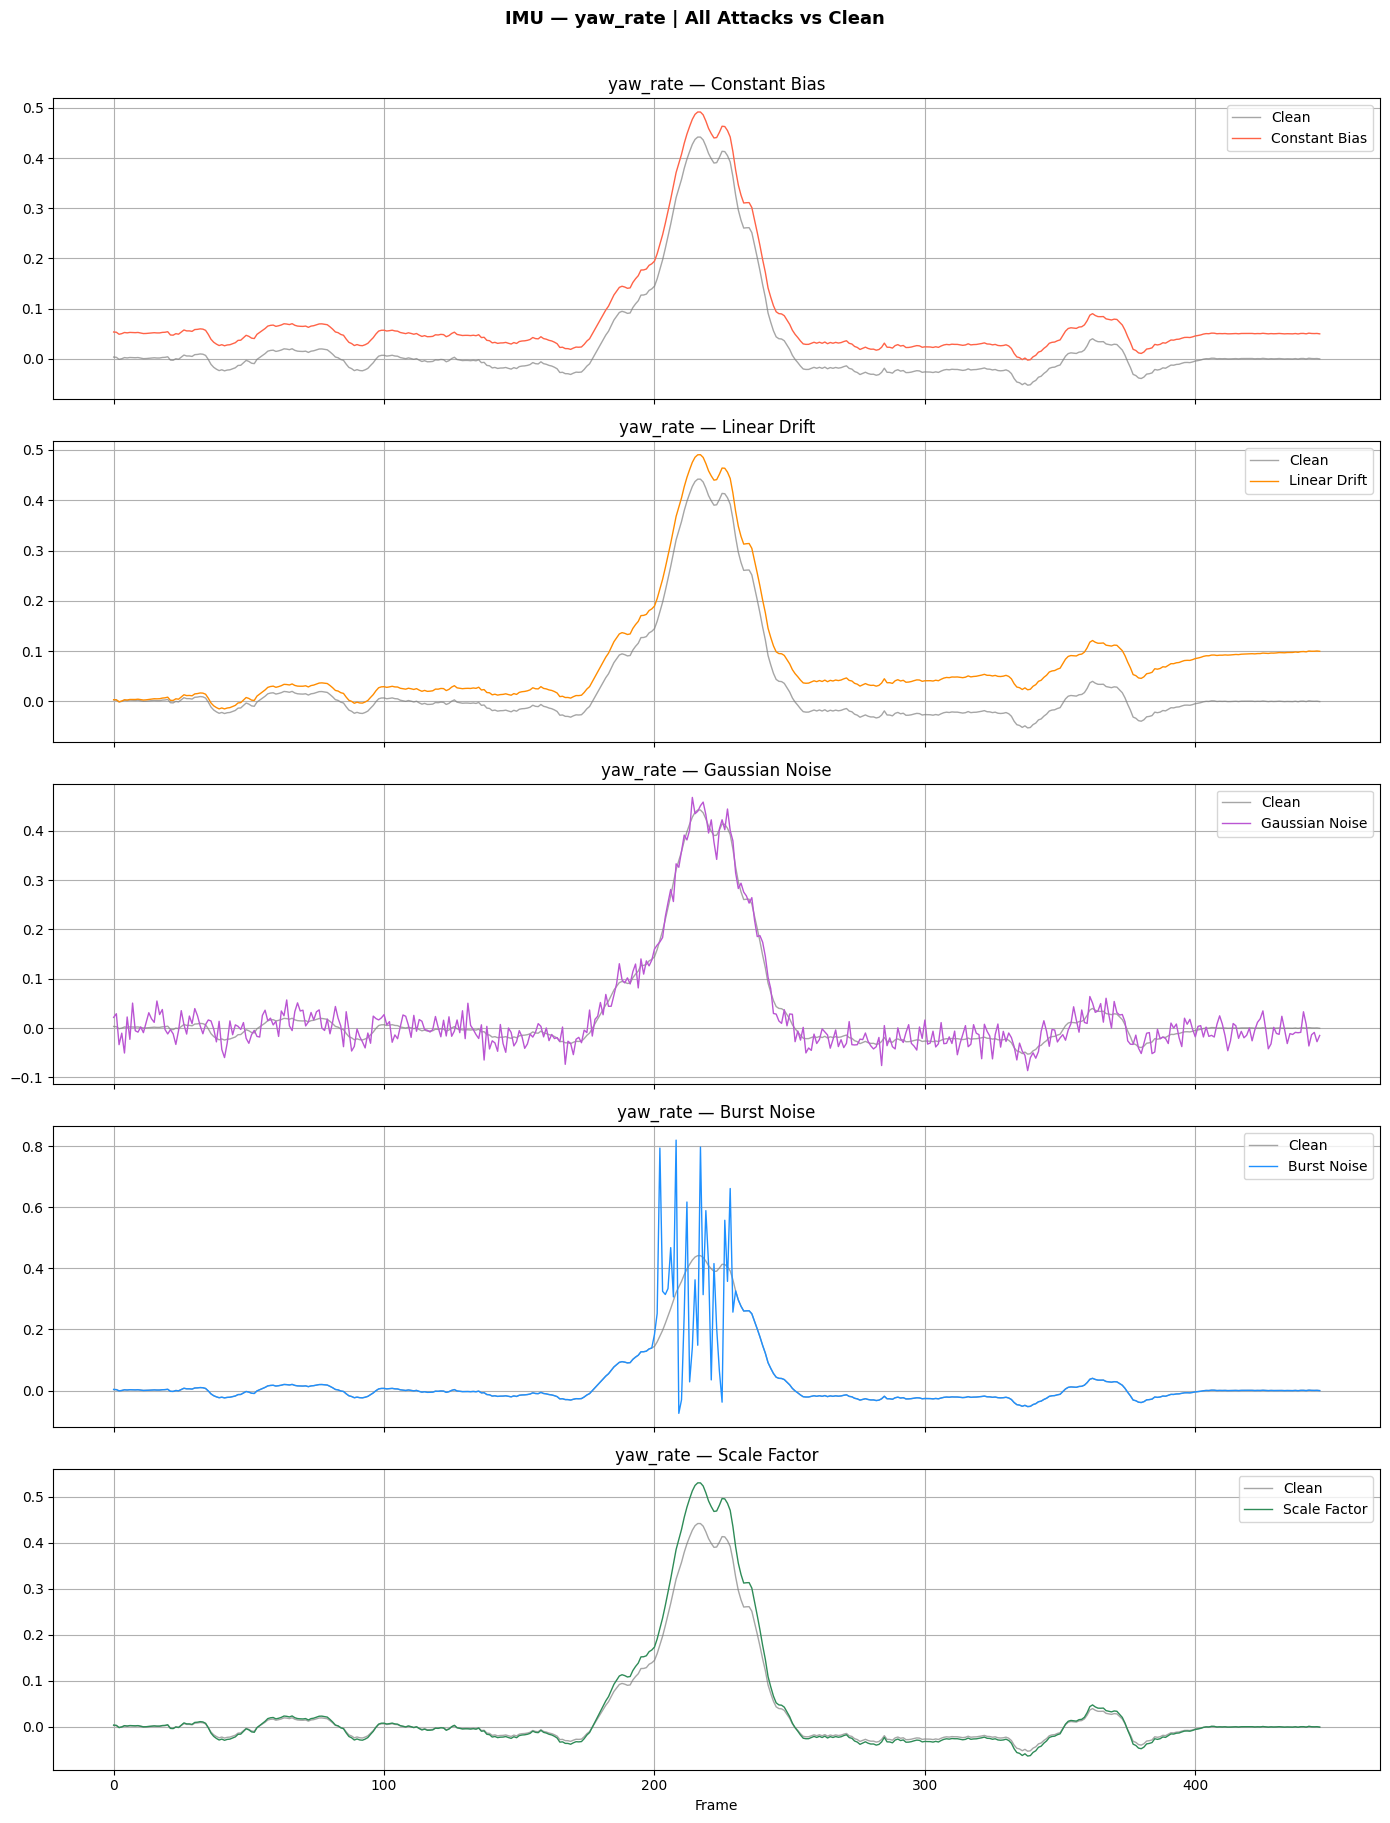

yaw_rate plotted


In [4]:
'''Plot All signals, all attacks'''

for signal_key in imu_clean.keys():
    fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)

    for i, (name, attacked) in enumerate(all_attacks.items()):
        axes[i].plot(imu_clean[signal_key], label="Clean", color="gray", linewidth=1, alpha=0.7)
        axes[i].plot(attacked[signal_key],  label=name,    color=colors[i], linewidth=1)
        axes[i].set_title(f"{signal_key} — {name}")
        axes[i].legend(loc="upper right")
        axes[i].grid(True)

    axes[-1].set_xlabel("Frame")
    plt.suptitle(f"IMU — {signal_key} | All Attacks vs Clean", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"{signal_key} plotted")

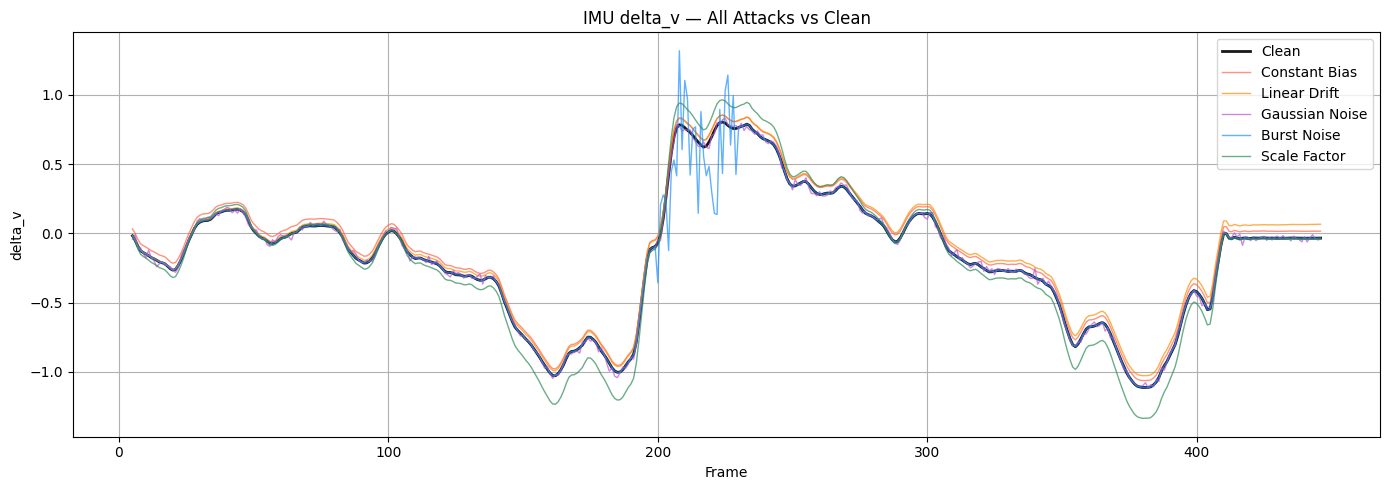

delta_v overlay plotted


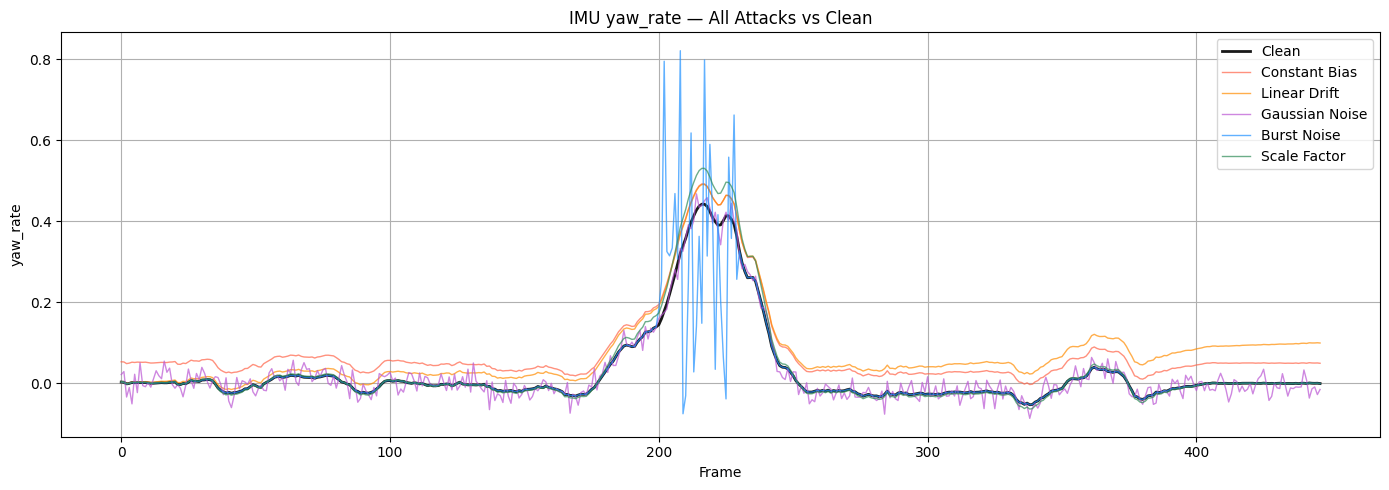

yaw_rate overlay plotted


In [5]:
'''Overlay — all attacks on one plot, per signal'''
for signal_key in imu_clean.keys():
    plt.figure(figsize=(14, 5))
    plt.plot(imu_clean[signal_key], label="Clean", color="black", linewidth=2, alpha=0.9)

    for name, attacked, color in zip(attack_names, all_attacks.values(), colors):
        plt.plot(attacked[signal_key], label=name, color=color, linewidth=1, alpha=0.7)

    plt.title(f"IMU {signal_key} — All Attacks vs Clean")
    plt.xlabel("Frame")
    plt.ylabel(signal_key)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    print(f"{signal_key} overlay plotted")

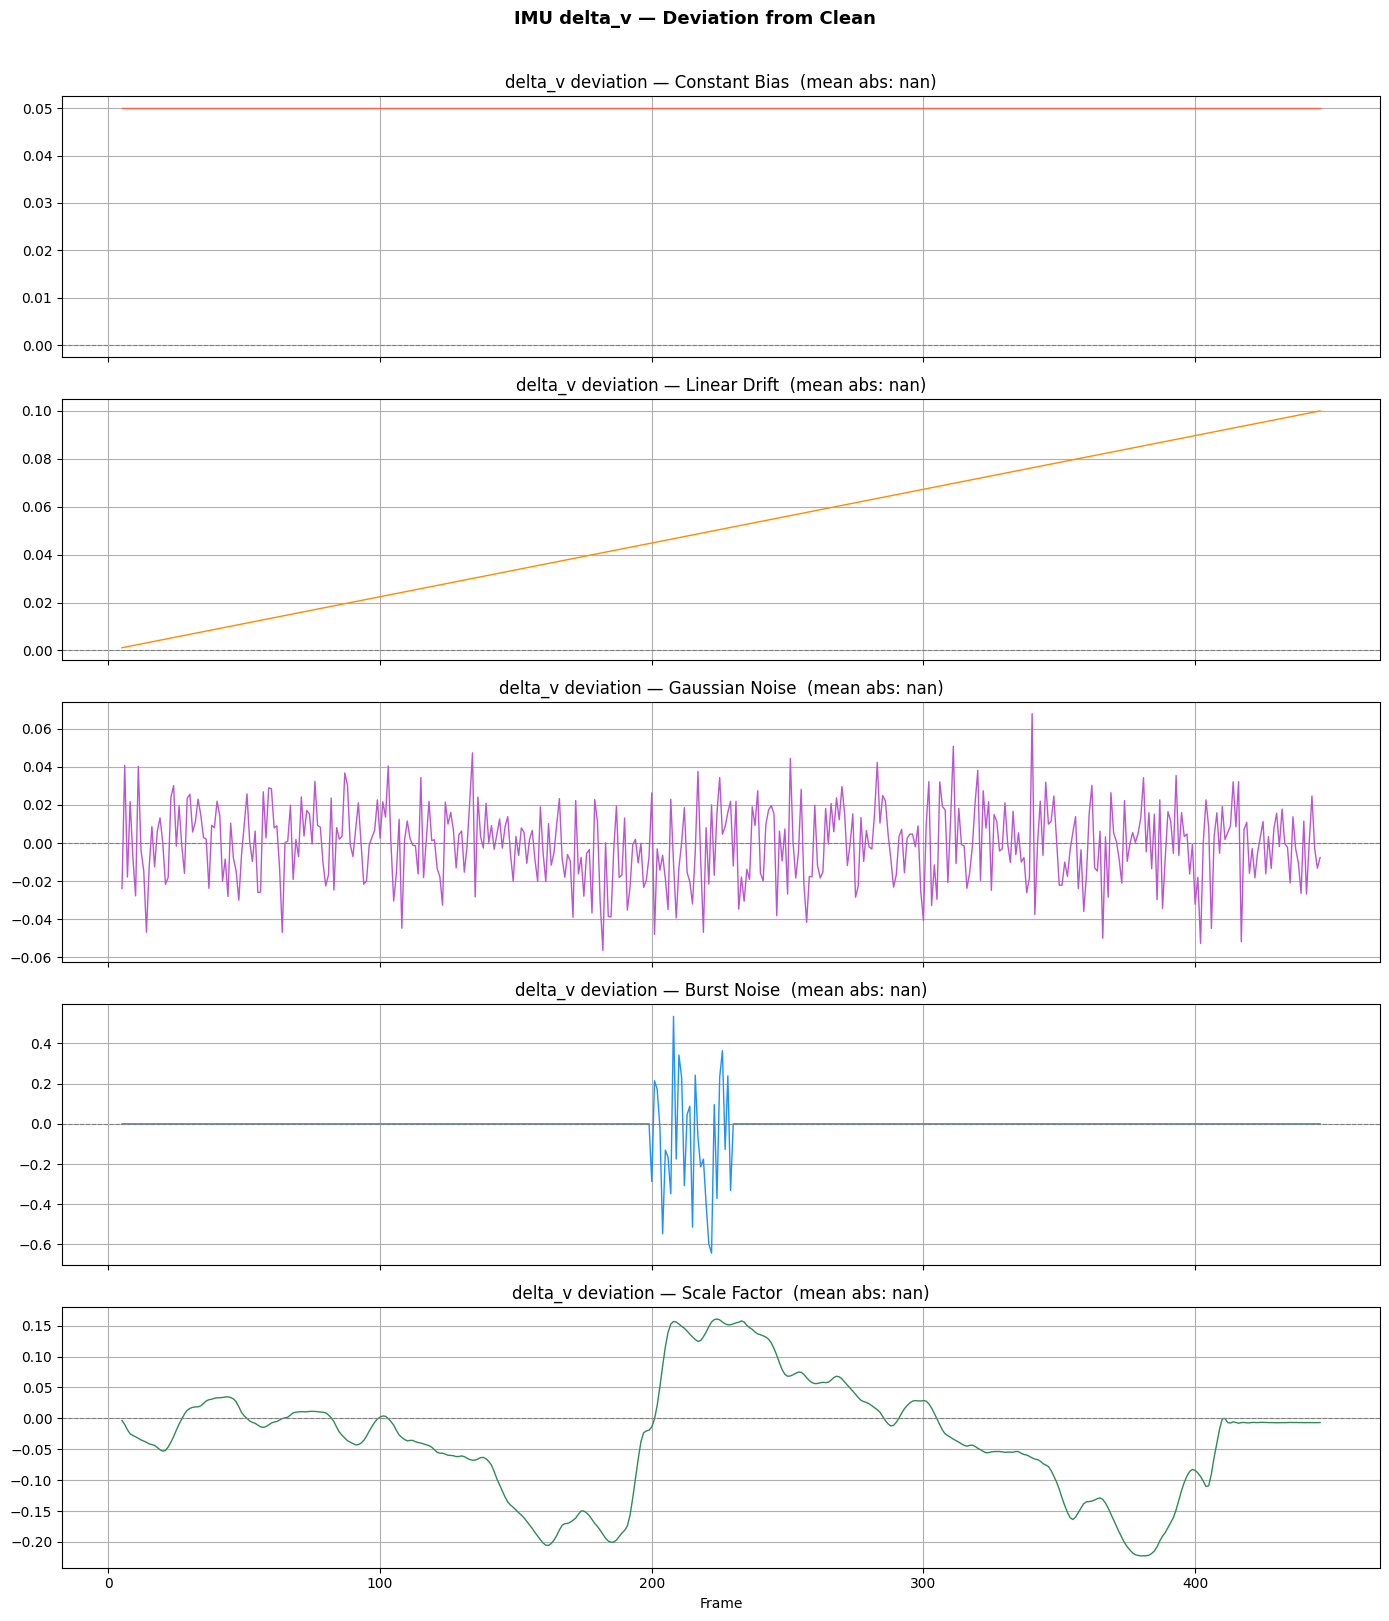

delta_v deviation plotted


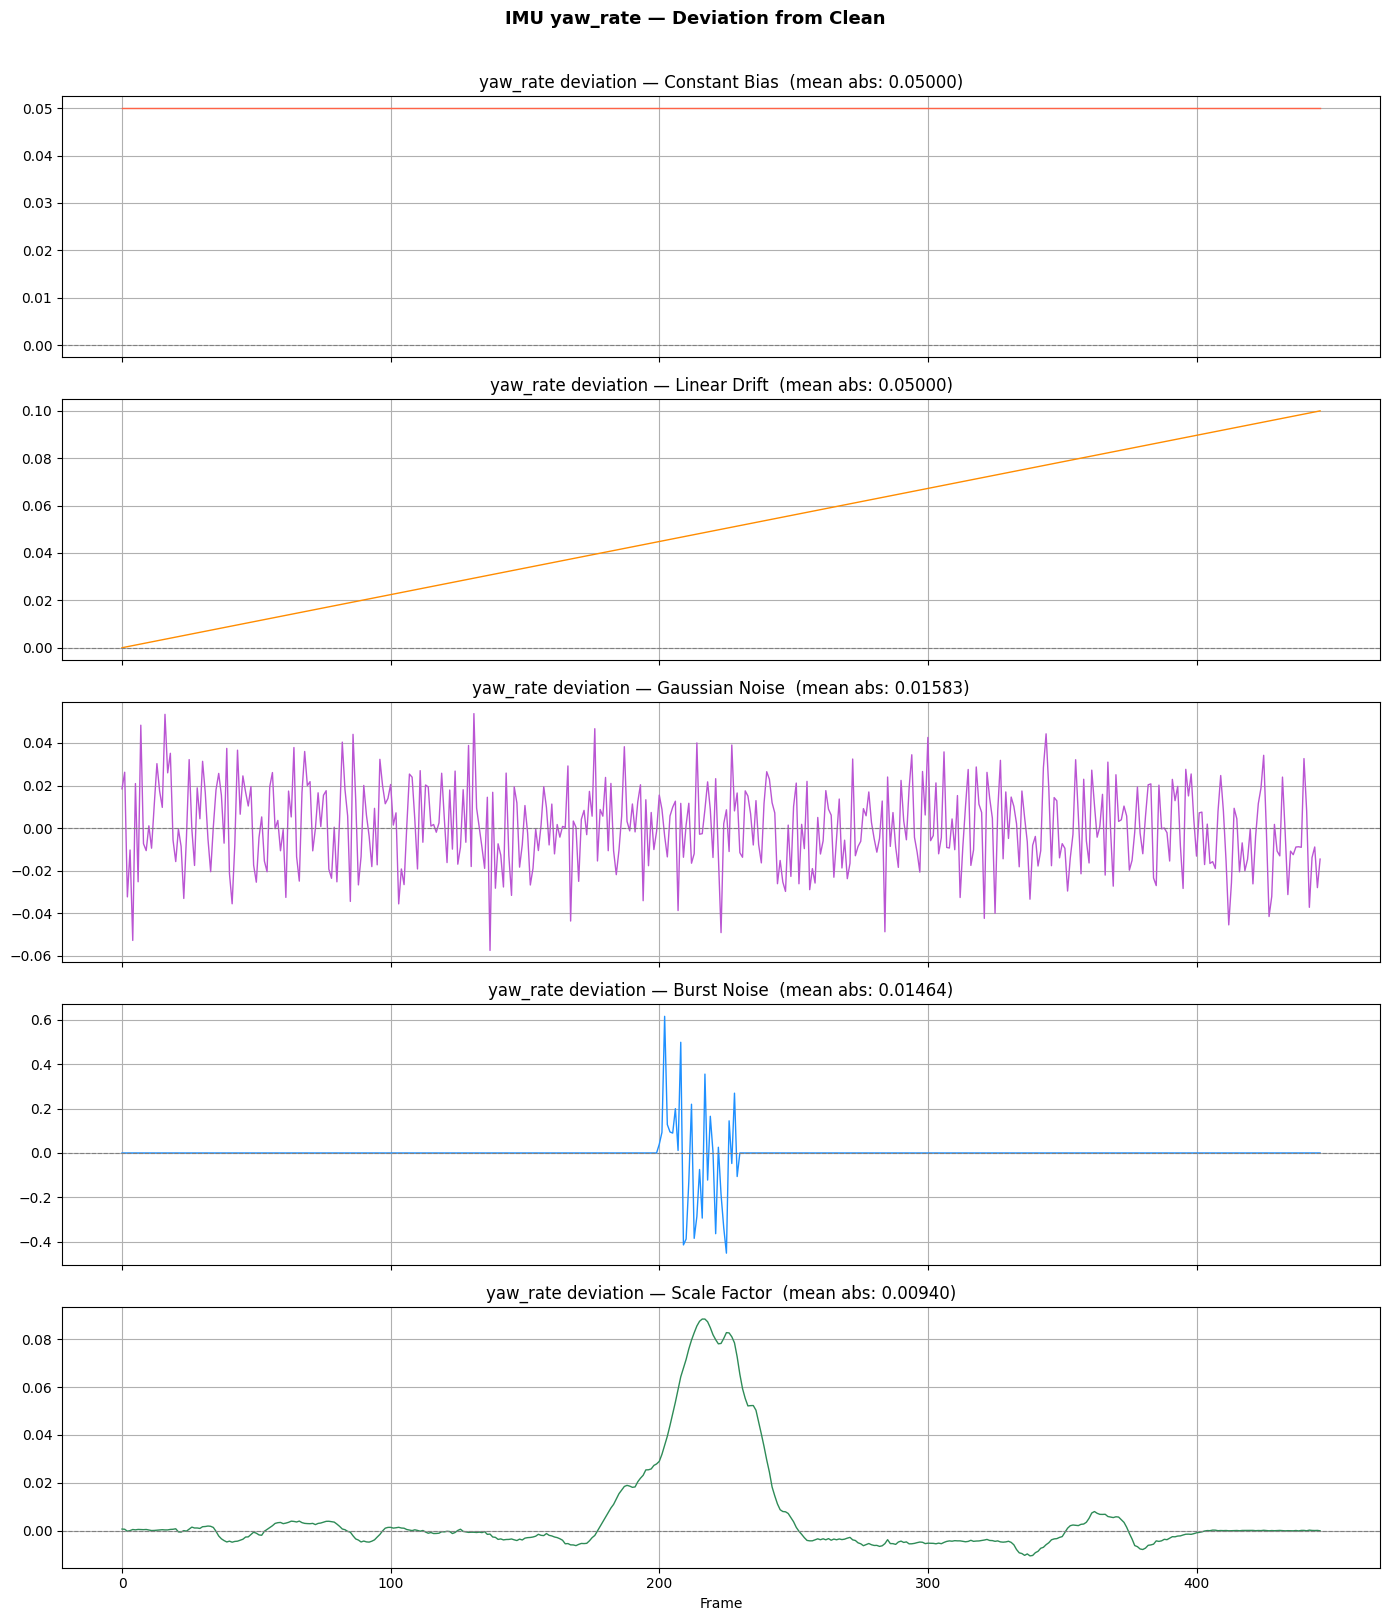

yaw_rate deviation plotted


In [6]:
'''Deviation signals, per signal'''
for signal_key in imu_clean.keys():
    fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

    for i, (name, attacked) in enumerate(all_attacks.items()):
        diff = attacked[signal_key] - imu_clean[signal_key]
        axes[i].plot(diff, color=colors[i], linewidth=1)
        axes[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
        axes[i].set_title(f"{signal_key} deviation — {name}  (mean abs: {np.mean(np.abs(diff)):.5f})")
        axes[i].grid(True)

    axes[-1].set_xlabel("Frame")
    plt.suptitle(f"IMU {signal_key} — Deviation from Clean", fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()
    print(f"{signal_key} deviation plotted")

In [7]:
#Stats Summary Table
print("\nIMU Attack Statistics — yaw_rate\n")
print(f"{'Attack':<20} | {'Mean Diff':>10} | {'Max Diff':>10} | {'Std Diff':>10}")
print("-" * 58)

for name, attacked in all_attacks.items():
    diff = np.abs(attacked["yaw_rate"] - imu_clean["yaw_rate"])
    print(f"{name:<20} | {np.mean(diff):>10.5f} | {np.max(diff):>10.5f} | {np.std(diff):>10.5f}")

print("\nIMU Attack Statistics — delta_v\n")
print(f"{'Attack':<20} | {'Mean Diff':>10} | {'Max Diff':>10} | {'Std Diff':>10}")
print("-" * 58)

for name, attacked in all_attacks.items():
    diff = np.abs(attacked["delta_v"] - imu_clean["delta_v"])
    print(f"{name:<20} | {np.mean(diff):>10.5f} | {np.max(diff):>10.5f} | {np.std(diff):>10.5f}")


IMU Attack Statistics — yaw_rate

Attack               |  Mean Diff |   Max Diff |   Std Diff
----------------------------------------------------------
Constant Bias        |    0.05000 |    0.05000 |    0.00000
Linear Drift         |    0.05000 |    0.10000 |    0.02893
Gaussian Noise       |    0.01583 |    0.05752 |    0.01135
Burst Noise          |    0.01464 |    0.61630 |    0.06835
Scale Factor         |    0.00940 |    0.08840 |    0.01887

IMU Attack Statistics — delta_v

Attack               |  Mean Diff |   Max Diff |   Std Diff
----------------------------------------------------------
Constant Bias        |        nan |        nan |        nan
Linear Drift         |        nan |        nan |        nan
Gaussian Noise       |        nan |        nan |        nan
Burst Noise          |        nan |        nan |        nan
Scale Factor         |        nan |        nan |        nan


In [8]:
# CAMERA BLOCK 1: Extract clean camera frames and proxies
camera_frames_clean = list(data.cam2)[:30]  # PIL images from KITTI

camera_clean = extract_all_camera_proxies(camera_frames_clean)

print(f"✅ Camera proxies extracted")
print(f"   Keys: {list(camera_clean.keys())}")
print(f"   Frames: {len(camera_frames_clean)}")
print(f"   flow_magnitude length: {len(camera_clean['flow_magnitude'])}") # N-1
print(f"   flow_magnitude mean: {np.mean(camera_clean['flow_magnitude']):.4f} px/frame")

✅ Camera proxies extracted
   Keys: ['flow_magnitude']
   Frames: 30
   flow_magnitude length: 29
   flow_magnitude mean: 13.0737 px/frame


In [9]:
# CAMERA BLOCK 2: Generate all attacked frame lists
# image-level attacks — apply to every frame
def attack_all_frames(frames, attack_fn, **kwargs):
    return [attack_fn(np.array(f), **kwargs) for f in frames]

from src.attacks.camera_attack import (
    gaussian_noise as cam_gaussian_noise,
    salt_pepper_noise,
    brightness_shift,
    motion_blur,
    occlusion,
    freeze_frames,
    drop_frames
)

frames_gaussian   = attack_all_frames(camera_frames_clean, cam_gaussian_noise, std=15)
frames_saltpepper = attack_all_frames(camera_frames_clean, salt_pepper_noise, probability=0.01)
frames_brightness = attack_all_frames(camera_frames_clean, brightness_shift, shift=40)
frames_motionblur = attack_all_frames(camera_frames_clean, motion_blur, kernel_size=15)
frames_occlusion  = attack_all_frames(camera_frames_clean, occlusion, x=200, y=100, w=200, h=150)

# these two take full list, not per-frame
frames_freeze     = freeze_frames(
                        [np.array(f) for f in camera_frames_clean],
                        start_frame=15, duration=10
                    )
frames_drop       = drop_frames(
                        [np.array(f) for f in camera_frames_clean],
                        interval=5
                    )

print("All 7 camera attack frame lists generated")

All 7 camera attack frame lists generated


In [10]:
# CAMERA BLOCK 3: Extract proxies from all attacked frames
camera_gaussian   = extract_all_camera_proxies(frames_gaussian)
camera_saltpepper = extract_all_camera_proxies(frames_saltpepper)
camera_brightness = extract_all_camera_proxies(frames_brightness)
camera_motionblur = extract_all_camera_proxies(frames_motionblur)
camera_occlusion  = extract_all_camera_proxies(frames_occlusion)
camera_freeze     = extract_all_camera_proxies(frames_freeze)
camera_drop       = extract_all_camera_proxies(frames_drop)

all_camera_attacks = {
    "Gaussian Noise":  camera_gaussian,
    "Salt & Pepper":   camera_saltpepper,
    "Brightness Shift":camera_brightness,
    "Motion Blur":     camera_motionblur,
    "Occlusion":       camera_occlusion,
    "Freeze Frames":   camera_freeze,
    "Drop Frames":     camera_drop,
}

cam_colors = ["tomato", "darkorange", "mediumorchid", "dodgerblue", "seagreen", "crimson", "teal"]

print("All 7 camera proxies extracted")
for name, attacked in all_camera_attacks.items():
    diff = np.mean(np.abs(attacked["flow_magnitude"] - camera_clean["flow_magnitude"]))
    print(f"   {name:<20} | mean |flow_magnitude diff|: {diff:.5f}")

All 7 camera proxies extracted
   Gaussian Noise       | mean |flow_magnitude diff|: 2.04416
   Salt & Pepper        | mean |flow_magnitude diff|: 3.01470
   Brightness Shift     | mean |flow_magnitude diff|: 0.25527
   Motion Blur          | mean |flow_magnitude diff|: 2.14239
   Occlusion            | mean |flow_magnitude diff|: 1.50333
   Freeze Frames        | mean |flow_magnitude diff|: 4.56595
   Drop Frames          | mean |flow_magnitude diff|: 11.72354


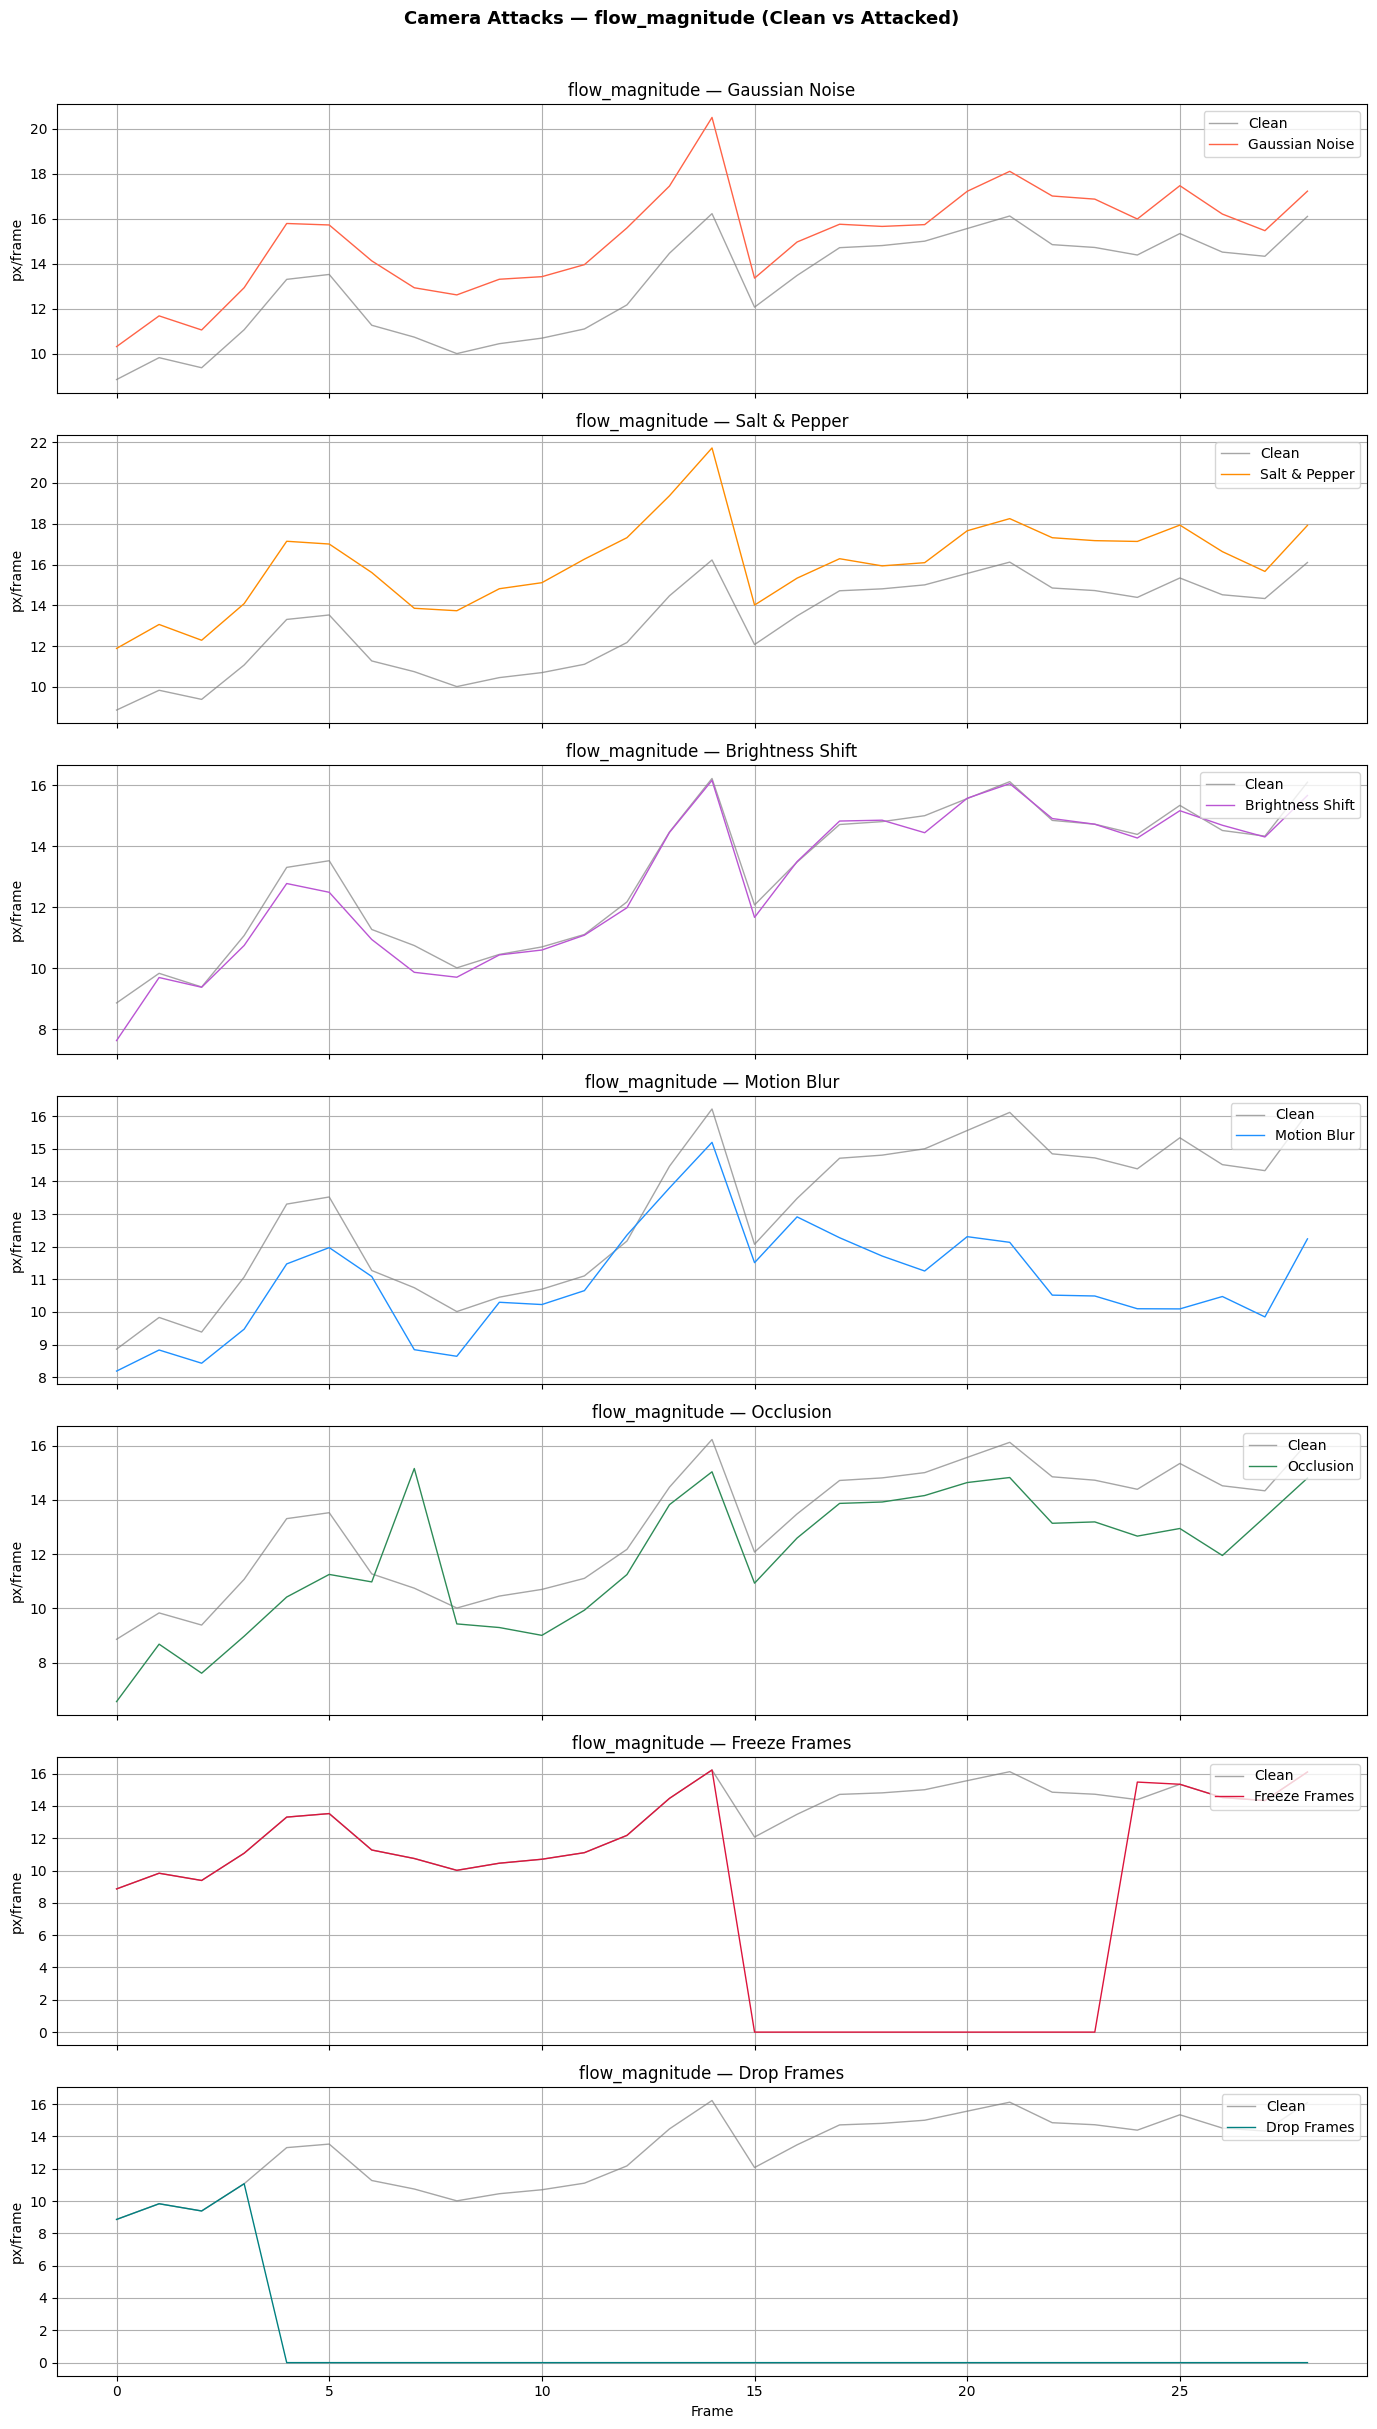

Camera subplots plotted


In [11]:
# CAMERA BLOCK 4: Subplots — clean vs each attack
fig, axes = plt.subplots(7, 1, figsize=(14, 24), sharex=True)

for i, (name, attacked) in enumerate(all_camera_attacks.items()):
    axes[i].plot(camera_clean["flow_magnitude"], label="Clean", color="gray", linewidth=1, alpha=0.7)
    axes[i].plot(attacked["flow_magnitude"],     label=name,    color=cam_colors[i], linewidth=1)
    axes[i].set_title(f"flow_magnitude — {name}")
    axes[i].set_ylabel("px/frame")
    axes[i].legend(loc="upper right")
    axes[i].grid(True)

axes[-1].set_xlabel("Frame")
plt.suptitle("Camera Attacks — flow_magnitude (Clean vs Attacked)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Camera subplots plotted")

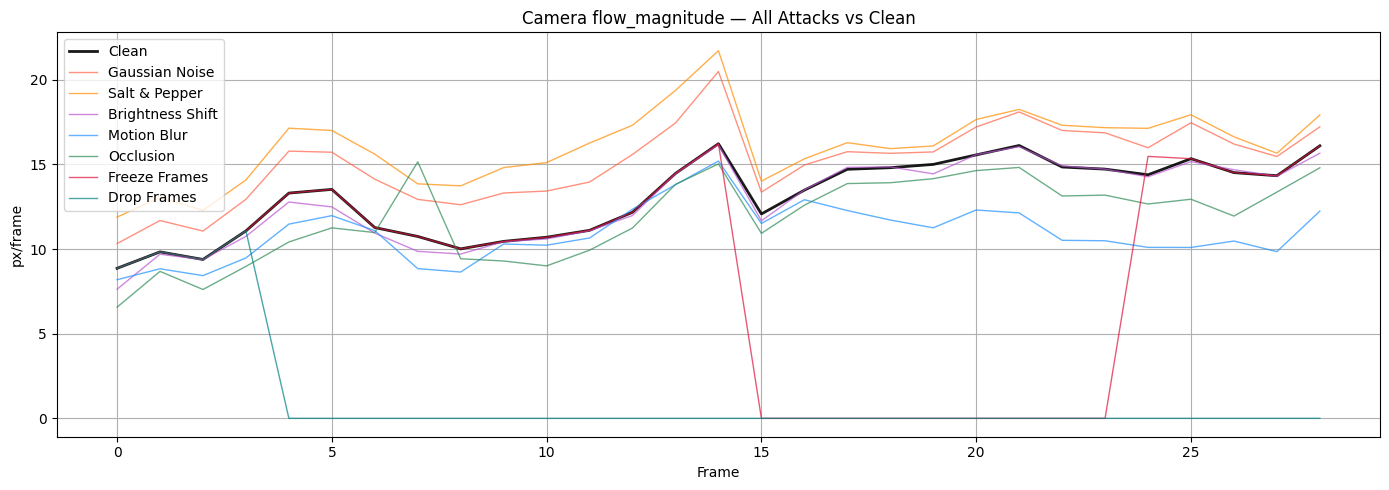

Camera overlay plotted


In [12]:
# CAMERA BLOCK 5: Overlay — all attacks on one plot
plt.figure(figsize=(14, 5))
plt.plot(camera_clean["flow_magnitude"], label="Clean", color="black", linewidth=2, alpha=0.9)

for name, attacked, color in zip(all_camera_attacks.keys(), all_camera_attacks.values(), cam_colors):
    plt.plot(attacked["flow_magnitude"], label=name, color=color, linewidth=1, alpha=0.7)

plt.title("Camera flow_magnitude — All Attacks vs Clean")
plt.xlabel("Frame")
plt.ylabel("px/frame")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Camera overlay plotted")

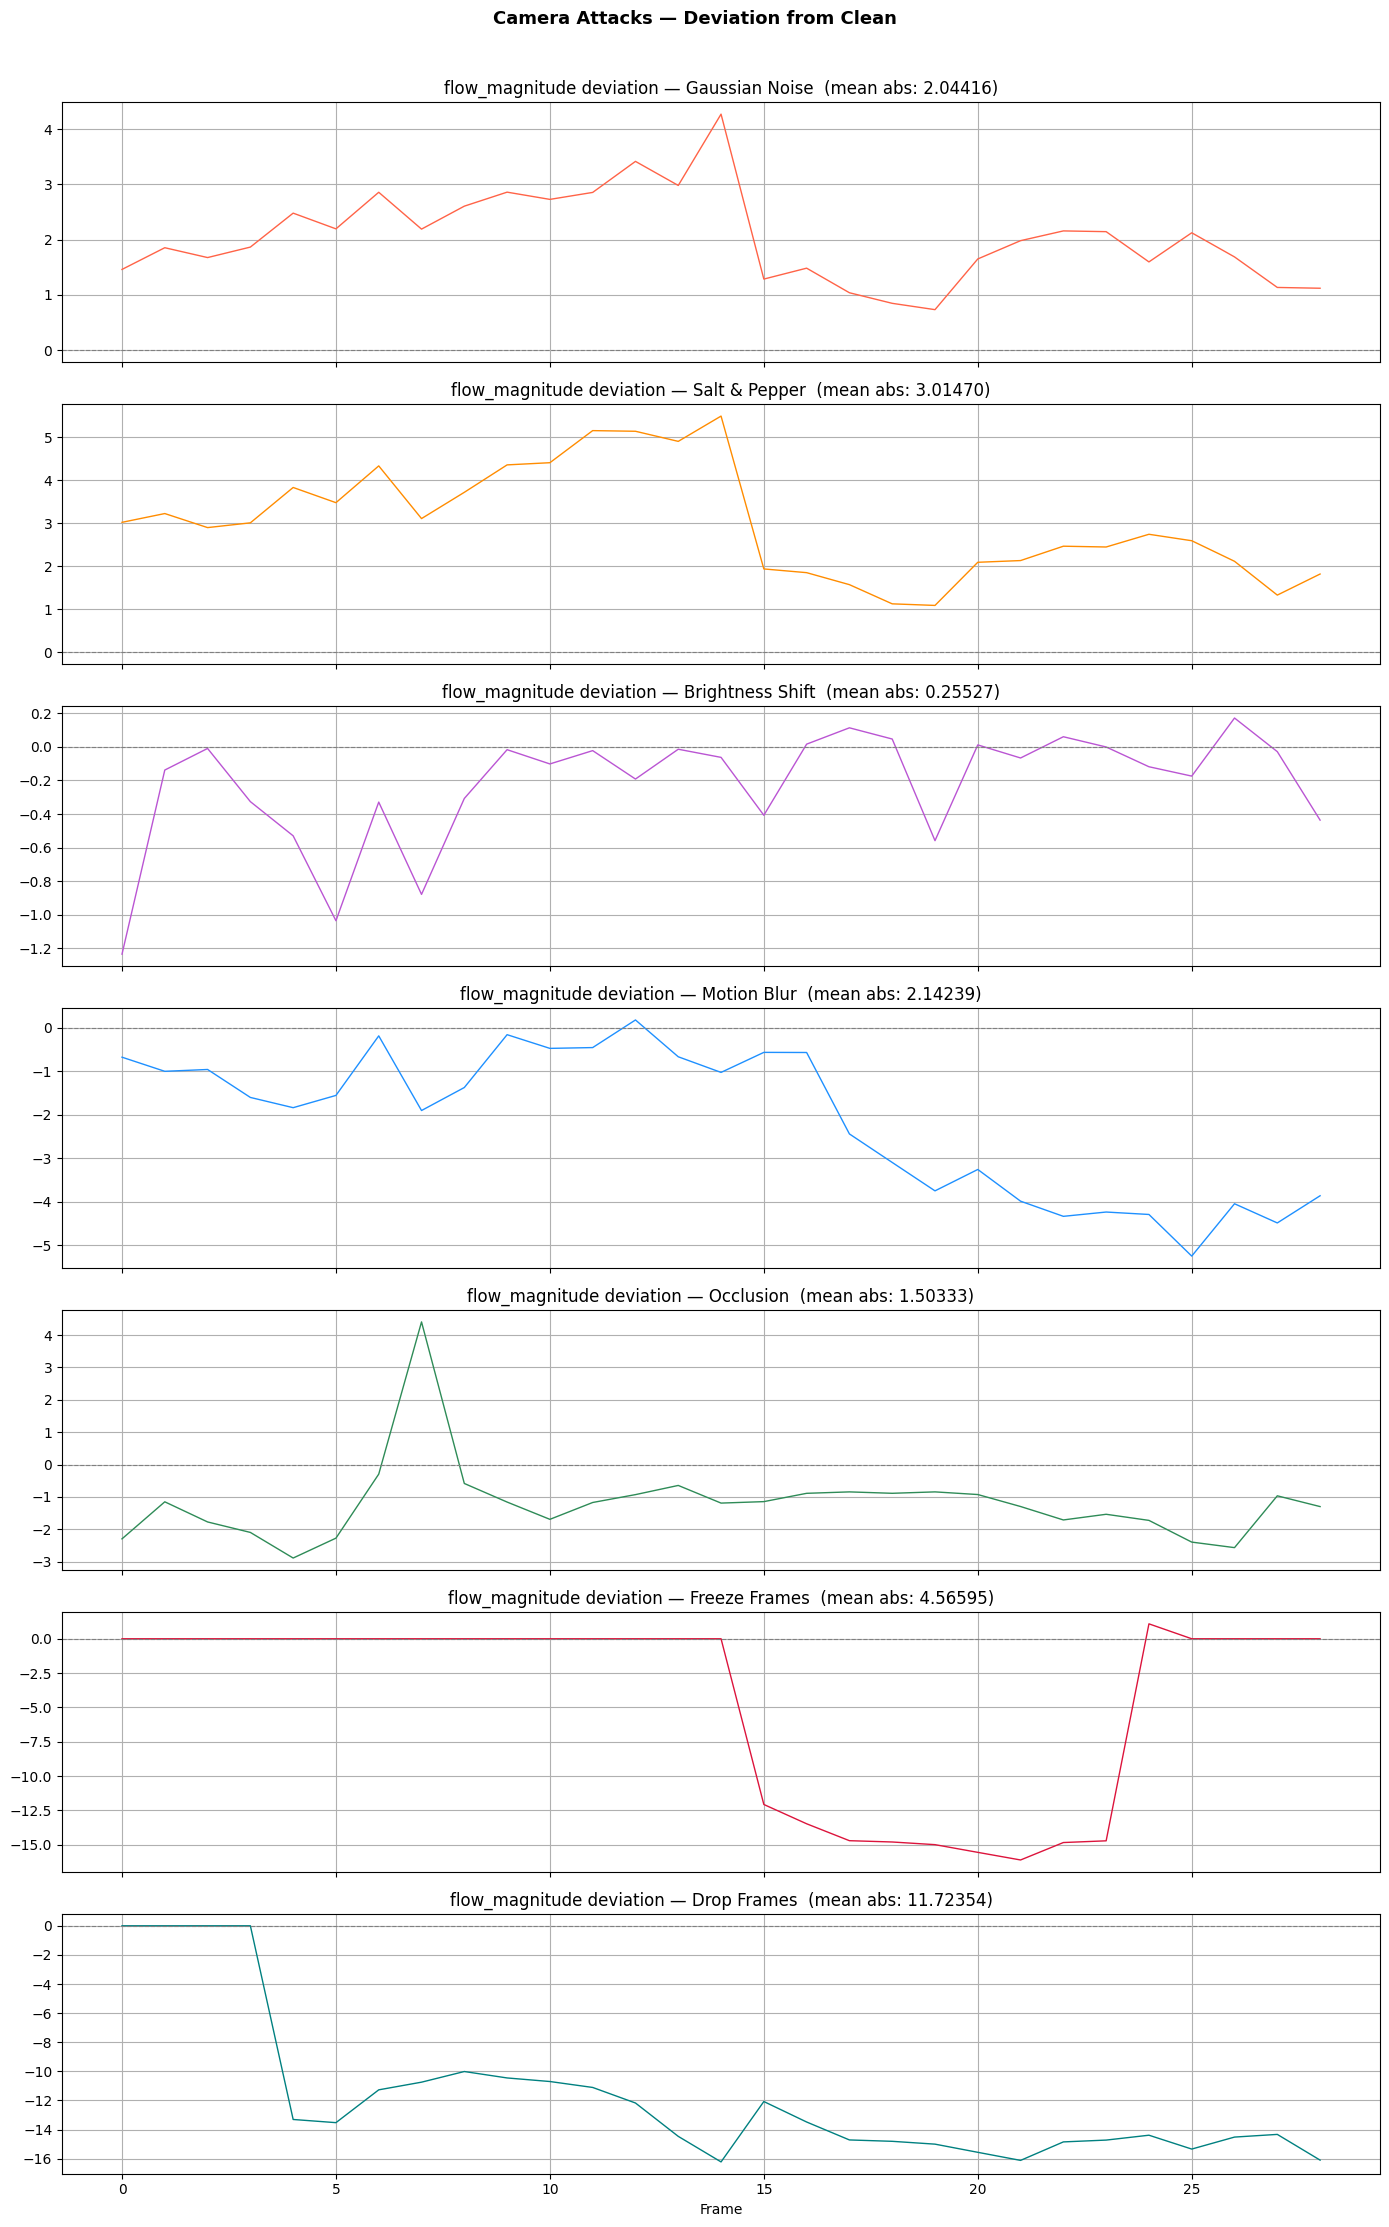

Camera deviation plotted


In [13]:
# CAMERA BLOCK 6: Deviation signals
fig, axes = plt.subplots(7, 1, figsize=(14, 22), sharex=True)

for i, (name, attacked) in enumerate(all_camera_attacks.items()):
    diff = attacked["flow_magnitude"] - camera_clean["flow_magnitude"]
    axes[i].plot(diff, color=cam_colors[i], linewidth=1)
    axes[i].axhline(0, color="gray", linestyle="--", linewidth=0.8)
    axes[i].set_title(f"flow_magnitude deviation — {name}  (mean abs: {np.mean(np.abs(diff)):.5f})")
    axes[i].grid(True)

axes[-1].set_xlabel("Frame")
plt.suptitle("Camera Attacks — Deviation from Clean", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Camera deviation plotted")

In [14]:
# CAMERA BLOCK 7: Stats table
print("\nCamera Attack Statistics — flow_magnitude\n")
print(f"{'Attack':<20} | {'Mean Diff':>10} | {'Max Diff':>10} | {'Std Diff':>10}")
print("-" * 58)

for name, attacked in all_camera_attacks.items():
    diff = np.abs(attacked["flow_magnitude"] - camera_clean["flow_magnitude"])
    print(f"{name:<20} | {np.mean(diff):>10.5f} | {np.max(diff):>10.5f} | {np.std(diff):>10.5f}")


Camera Attack Statistics — flow_magnitude

Attack               |  Mean Diff |   Max Diff |   Std Diff
----------------------------------------------------------
Gaussian Noise       |    2.04416 |    4.26879 |    0.79806
Salt & Pepper        |    3.01470 |    5.49485 |    1.24902
Brightness Shift     |    0.25527 |    1.23383 |    0.31621
Motion Blur          |    2.14239 |    5.24498 |    1.61430
Occlusion            |    1.50333 |    4.40887 |    0.83761
Freeze Frames        |    4.56595 |   16.11779 |    6.75690
Drop Frames          |   11.72354 |   16.22229 |    5.01632
